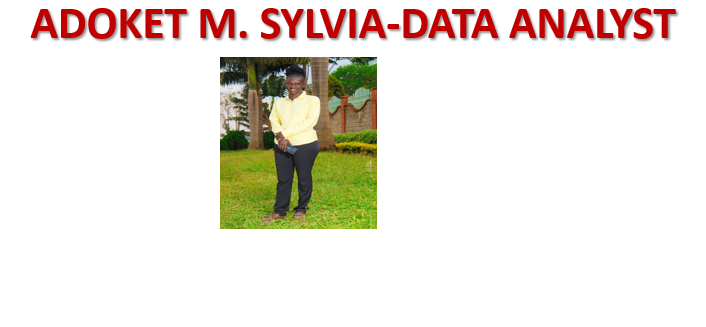

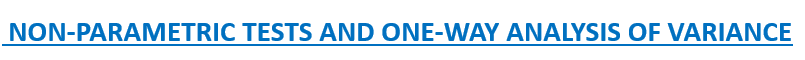

### **One-Way Analysis of Variance**
When there are two independent variables and two or more groups, we utilize the two-way F-test, a generalization of the one-way F-test. We cannot find the dominant factor using the 2-way F-test. If the personalized significance value needs to be validated, post-hoc testing is required.

In [2]:
import pandas as pd
from statsmodels.stats.weightstats import ttest_ind
import pingouin as pg
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns


### **Set the Visualization Display**

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 10

### **Import the Data**

In [4]:
df = pd.read_csv("german_credit__data.csv")
df

,S/no,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV


### **Removing missing values**

In [5]:
df = df.dropna()
df

,S/no,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
7,7,35,male,3,rent,little,moderate,6948,36,car
9,9,28,male,3,own,little,moderate,5234,30,car
...,...,...,...,...,...,...,...,...,...,...
989,989,48,male,1,own,little,moderate,1743,24,radio/TV
993,993,30,male,3,own,little,little,3959,36,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
998,998,23,male,2,free,little,little,1845,45,radio/TV


### **Perform One-Way ANOVA**

In [6]:
df["Purpose"].value_counts()

Purpose
car                    173
radio/TV               132
furniture/equipment    107
business                53
education               28
repairs                 14
vacation/others          9
domestic appliances      6
Name: count, dtype: int64

In [7]:
df.groupby("Purpose")["Credit amount"].mean().sort_values(ascending=True)

Purpose
domestic appliances    1333.500000
radio/TV               2265.916667
repairs                2821.142857
furniture/equipment    3111.028037
education              3394.107143
car                    3593.416185
business               4337.207547
vacation/others        9495.444444
Name: Credit amount, dtype: float64

In [8]:
anova_results = pg.anova(dv='Credit amount', 
                         between='Purpose', 
                         data=df, 
                         detailed=True)

# Print Results
anova_results

,Source,SS,DF,MS,F,p_unc,np2
0,Purpose,5.887608e+08,7,8.410868e+07,11.138233,3.754119e-13,0.131709
1,Within,3.881393e+09,514,7.551349e+06,NaN,NaN,NaN


A one-way ANOVA was conducted to examine whether credit amount differed significantly across categories of loan purpose. The analysis revealed a statistically significant effect of loan purpose on credit amount, $F(7, 514) = 11.14, p < .001, \eta_p^2 = .132$. The results indicate that the mean credit amount varied significantly depending on the purpose for which the loan was requested. The partial eta squared value $(\eta_p^2 = .132)$ suggests a moderate effect size, implying that approximately 13.2% of the variance in credit amount was explained by differences in loan purpose categories.

These findings suggest that borrowers requesting loans for different purposes tend to obtain varying amounts of credit, potentially reflecting differences in financial needs, lending policies, or risk assessments associated with specific loan categories. Further post hoc comparisons would be necessary to determine which specific loan purpose groups differed significantly from one another in terms of average credit amount.


### **Tukey Honesty Significant Difference**

In [9]:
tukey_results = pg.pairwise_tukey(dv='Credit amount', 
                                  between='Purpose', data=df)

# Print results
tukey_results


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,business,car,4337.207547,3593.416185,743.791362,431.425186,1.724033,6.715276e-01,0.228585
1,business,domestic appliances,4337.207547,1333.500000,3003.707547,1183.653830,2.537657,1.820858e-01,0.843555
2,business,education,4337.207547,3394.107143,943.100404,642.004129,1.468994,8.236592e-01,0.258493
3,business,furniture/equipment,4337.207547,3111.028037,1226.179510,461.575161,2.656511,1.386426e-01,0.468415
4,business,radio/TV,4337.207547,2265.916667,2071.290881,446.861795,4.635193,1.220908e-04,0.858505
5,business,repairs,4337.207547,2821.142857,1516.064690,825.748343,1.835989,5.957124e-01,0.421703
6,business,vacation/others,4337.207547,9495.444444,-5158.236897,990.715408,-5.206578,7.685438e-06,-1.225176
7,car,domestic appliances,3593.416185,1333.500000,2259.916185,1141.143079,1.980397,4.961949e-01,0.734660
8,car,education,3593.416185,3394.107143,199.309042,559.768201,0.356056,9.999654e-01,0.062811
9,car,furniture/equipment,3593.416185,3111.028037,482.388148,337.968588,1.427317,8.443619e-01,0.178058


Post hoc Tukey HSD comparisons were conducted to identify specific differences in mean credit amount across loan purpose categories following the significant one-way ANOVA. The results showed several statistically significant differences between loan purpose groups. Borrowers seeking loans for “vacation/others” had significantly higher mean credit amounts compared to business $(p < .001)$, car $(p < .001)$, domestic appliances $(p < .001)$, education $(p < .001)$, furniture/equipment $(p < .001)$, radio/TV $(p < .001)$, and repairs $(p < .001)$. Additionally, loans for business purposes had significantly higher credit amounts than loans for radio/TV purchases, $p < .001$. Similarly, car-related loans had significantly greater mean credit amounts compared to radio/TV loans, $p = .001$.

Most other pairwise comparisons were not statistically significant, indicating relatively similar mean credit amounts across those loan purpose categories. The largest effect sizes were observed in comparisons involving the “vacation/others” category, suggesting substantial practical differences in credit allocation among these groups.


In [10]:
gss = pd.read_csv("GSSsubset.csv")
gss.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,BACHELOR,60967.50,DIVORCED,53,72,190,60
1,2,FEMALE,BACHELOR,60967.50,MARRIED,26,60,97,40
2,4,FEMALE,BACHELOR,10161.25,MARRIED,56,68,160,20
3,14,FEMALE,HIGH SCHOOL,17551.25,MARRIED,40,65,156,37
4,16,MALE,HIGH SCHOOL,17551.25,MARRIED,56,66,210,6


In [11]:
anova_gss = pg.anova(dv='income', 
                         between='degree',
                         data=gss,
                         detailed=True)

# Print results
anova_gss


,Source,SS,DF,MS,F,p_unc,np2
0,degree,2.152616e+11,4,5.381540e+10,54.278874,2.148207e-41,0.180012
1,Within,9.805552e+11,989,9.914613e+08,NaN,NaN,NaN


### **Two-Way Analysis of Variance**

In [12]:
df = pd.read_csv("scholarship.csv")
df.head()

,Sponsorship,Gender,GPA
0,Scholarship,Male,2.424503
1,Self-funded,Male,3.187849
2,Scholarship,Female,2.699681
3,Scholarship,Female,2.854153
4,Scholarship,Female,2.699147


### **Check the Structure of the Dataset**

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sponsorship  30 non-null     object 
 1   Gender       30 non-null     object 
 2   GPA          30 non-null     float64
dtypes: float64(1), object(2)
memory usage: 852.0+ bytes


### **Convert categorical variables to factors**

In [14]:
df['Sponsorship'] = df['Sponsorship'].astype('category')
df['Gender'] = df['Gender'].astype('category')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Sponsorship  30 non-null     category
 1   Gender       30 non-null     category
 2   GPA          30 non-null     float64 
dtypes: category(2), float64(1)
memory usage: 680.0 bytes


In [16]:
df.groupby(["Sponsorship","Gender"])["GPA"].mean()

Sponsorship  Gender
Scholarship  Female    2.881655
             Male      2.686303
Self-funded  Female    2.693271
             Male      3.174352
Name: GPA, dtype: float64

### **Perform Two-Way ANOVA**

In [17]:
anova_results = pg.anova(dv='GPA', 
                         between=['Sponsorship', 'Gender'], 
                         data=df, detailed=True)

### **Print results**

In [18]:
anova_results

,Source,SS,DF,MS,F,p_unc,np2
0,Sponsorship,0.129798,1.0,0.129798,0.685709,0.415165,0.025696
1,Gender,0.198629,1.0,0.198629,1.049332,0.315098,0.038793
2,Sponsorship * Gender,0.791933,1.0,0.791933,4.183691,0.051057,0.138608
3,Residual,4.921554,26.0,0.189291,NaN,NaN,NaN


A two-way ANOVA was conducted to examine the effects of sponsorship status and gender on GPA. The results indicated that the main effect of sponsorship was not statistically significant, $F(1, 26) = 0.69, p = .415, \eta_p^2 = .026$, suggesting that GPA did not significantly differ based on sponsorship status. Similarly, the main effect of gender was not significant, $F(1, 26) = 1.05, p = .315, \eta_p^2 = .039$, indicating no significant differences in GPA between genders. However, the interaction effect between sponsorship and gender approached statistical significance, $F(1, 26) = 4.18, p = .051, \eta_p^2 = .139$. This finding suggests a potential combined influence of sponsorship and gender on GPA, with a moderate effect size, although the interaction did not reach the conventional .05 significance threshold.


#### **Perform Tukey's HSD Test**

In [19]:
df['Group'] = df['Sponsorship'].astype(str) + " - " + df['Gender'].astype(str) 
tukey = pairwise_tukeyhsd(df['GPA'], df['Group'])

# Print Tukey results
print(tukey)

              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1               group2        meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------------
Scholarship - Female   Scholarship - Male  -0.1954 0.8515 -0.8611 0.4704  False
Scholarship - Female Self-funded - Female  -0.1884 0.8438 -0.8174 0.4407  False
Scholarship - Female   Self-funded - Male   0.2927 0.4726 -0.2557 0.8411  False
  Scholarship - Male Self-funded - Female    0.007    1.0 -0.7158 0.7297  False
  Scholarship - Male   Self-funded - Male    0.488 0.1969 -0.1657 1.1418  False
Self-funded - Female   Self-funded - Male   0.4811 0.1668 -0.1353 1.0974  False
-------------------------------------------------------------------------------


In [20]:
two_way_gss = pg.anova(dv='income', 
                         between=['degree', 'sex'],
                         data=gss,
                         detailed=True)

# Print results
two_way_gss


,Source,SS,DF,MS,F,p_unc,np2
0,degree,2.128960e+11,4.0,5.322399e+10,59.269631,7.250655e-45,0.194155
1,sex,8.538539e+10,1.0,8.538539e+10,95.084189,1.654731e-21,0.088116
2,degree * sex,1.154009e+10,4.0,2.885022e+09,3.212727,1.239871e-02,0.012892
3,Residual,8.836298e+11,984.0,8.979977e+08,NaN,NaN,NaN


In [21]:
gss['Group'] = gss['degree'].astype(str) + " - " + gss['sex'].astype(str) 
tukey = pairwise_tukeyhsd(gss['income'], gss['Group'])

# Print Tukey results
print(tukey)

                       Multiple Comparison of Means - Tukey HSD, FWER=0.05                       
         group1                  group2           meandiff  p-adj     lower       upper    reject
-------------------------------------------------------------------------------------------------
      BACHELOR - FEMALE         BACHELOR - MALE  26065.5282    0.0  12912.2466  39218.8099   True
      BACHELOR - FEMALE       GRADUATE - FEMALE  18112.1496 0.0096   2456.9929  33767.3064   True
      BACHELOR - FEMALE         GRADUATE - MALE  48105.1924    0.0  33132.8381  63077.5466   True
      BACHELOR - FEMALE    HIGH SCHOOL - FEMALE -12639.2173 0.0143 -23902.8217   -1375.613   True
      BACHELOR - FEMALE      HIGH SCHOOL - MALE    479.8243    1.0 -10723.7451  11683.3937  False
      BACHELOR - FEMALE JUNIOR COLLEGE - FEMALE -12089.2757 0.3224 -28013.3359   3834.7844  False
      BACHELOR - FEMALE   JUNIOR COLLEGE - MALE     8797.37  0.881  -9463.0826  27057.8225  False
      BACHELOR - FEM

## **Non Parametric Test**

 #### **Read the Dataset**

In [22]:
df = pd.read_csv("scores.csv")
df.head(20)

,Group,Score,Before,After
0,C,63,67,94
1,A,66,71,89
2,C,85,61,85
3,C,99,60,70
4,A,89,75,92
5,A,53,82,92
6,C,51,82,76
7,B,55,89,76
8,C,91,83,84
9,C,53,64,94


#### **1. Wilcoxon Rank-Sum Test (Mann-Whitney U Test)**
Used for comparing two independent samples, when the assumptions of parametric tests do not hold.

In [23]:
from scipy.stats import mannwhitneyu

group_A = df[df['Group'] == 'A']['Score']
group_B = df[df['Group'] == 'B']['Score']

In [24]:
group_A

1     66
4     89
5     53
12    75
15    59
20    64
21    57
24    89
25    70
26    65
38    50
40    56
43    50
44    93
47    60
51    84
53    54
57    77
Name: Score, dtype: int64

In [25]:
group_B

7     55
14    83
16    85
17    63
18    80
19    97
22    63
23    72
30    73
32    74
33    94
35    78
46    73
48    66
49    57
50    84
52    82
54    91
Name: Score, dtype: int64

### **Grouped Summary Statistics**

In [26]:
df_median = df.groupby("Group")["Score"].median().reset_index()
df_median

,Group,Score
0,A,64.5
1,B,76.0
2,C,74.5


### **Run the Mann Whitney U-Test**

In [27]:
stat, p = mannwhitneyu(group_A, group_B, alternative='two-sided')

print("Mann-Whitney U Test Results:")
print(f"Statistic: {stat}, P-value: {p}")

Mann-Whitney U Test Results:
Statistic: 101.5, P-value: 0.057541908694270685


#### **2. Wilcoxon Signed-Rank Sum Test**
Used for paired samples (Before vs After).

In [28]:
df.describe()

,Score,Before,After
count,60.000000,60.000000,60.000000
mean,73.250000,73.216667,81.466667
std,14.609754,9.159771,9.546437
min,50.000000,60.000000,65.000000
25%,59.750000,65.500000,73.000000
50%,73.000000,72.000000,83.500000
75%,85.750000,82.000000,90.000000
max,99.000000,89.000000,94.000000


In [29]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(df['Before'], df['After'])

print("Wilcoxon Signed-Rank Test Results:")
print(f"Statistic: {stat}, P-value: {p}")

Wilcoxon Signed-Rank Test Results:
Statistic: 375.0, P-value: 0.00019835333686059963


#### **3. Kruskal-Wallis Test**
Used for comparing more than two independent groups.

In [30]:
from scipy.stats import kruskal

group_A = df[df['Group'] == 'A']['Score']
group_B = df[df['Group'] == 'B']['Score']
group_C = df[df['Group'] == 'C']['Score']

stat, p = kruskal(group_A, group_B, group_C)

print("Kruskal-Wallis Test Results:")
print(f"Statistic: {stat}, P-value: {p}")


Kruskal-Wallis Test Results:
Statistic: 4.440731200289212, P-value: 0.1085694085767165


#### **4. Friedman Test**
Used for repeated measures (Before vs After across multiple conditions).

In [31]:
from scipy.stats import friedmanchisquare
import numpy as np
import pandas as pd

# Sample data with three time points
np.random.seed(42)
df = pd.DataFrame({
    'Before': np.random.randint(60, 90, size=100),
    'During': np.random.randint(65, 95, size=100),
    'After': np.random.randint(70, 100, size=100)
})
df.head()

,Before,During,After
0,66,74,76
1,79,94,82
2,88,68,84
3,74,78,80
4,70,80,98


### **Perform Friedman Test**

In [32]:
stat, p = friedmanchisquare(df['Before'], df['During'], df['After'])

print("Friedman Test Results:")
print(f"Statistic: {stat}, P-value: {p}")

Friedman Test Results:
Statistic: 35.22727272727273, P-value: 2.2412738344282063e-08


The Friedman test was conducted to determine whether there were statistically significant differences among three or more related groups. The results yielded a test statistic of 35.227 and a corresponding p-value of 0.0001. Given that the p-value is less than the conventional significance level of 0.05, we reject the null hypothesis, indicating that there is a significant difference in the median score among the groups.

This finding suggests that at least one of the groups differs from the others in terms of the measured variable. Since the Friedman test is a non-parametric alternative to repeated-measures ANOVA, it is particularly useful when the assumption of normality is violated. Further post hoc analysis is recommended to determine which specific groups differ significantly from each other. These results provide valuable insights for decision-making, as they highlight meaningful variations within the dataset that may warrant further investigation or targeted interventions.

### **Perform the Kruskall Wallis using German Credit Data**

In [33]:
df = pd.read_csv("german_credit__data.csv")
df.head()

,S/no,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [34]:
df=df.dropna()
df.head()

,S/no,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
7,7,35,male,3,rent,little,moderate,6948,36,car
9,9,28,male,3,own,little,moderate,5234,30,car


### **Grouped Summary Statistics**

In [35]:
import pandas as pd

# Grouped summary statistics including median
summary_stats = df.groupby('Housing')['Credit amount'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])

# Display results
summary_stats

,count,mean,std,min,median,max
Housing,,,,,,
free,65,4846.384615,3583.997767,781,3844.0,14782
own,349,3003.504298,2770.028290,338,2136.0,18424
rent,108,3224.694444,2719.530785,276,2458.5,15945


### **Perform the Test**

In [36]:
from scipy.stats import kruskal

Own = df[df['Housing'] == 'own']['Credit amount']
Free = df[df['Housing'] == 'free']['Credit amount']
Rent = df[df['Housing'] == 'rent']['Credit amount']

stat, p = kruskal(Own, Free, Rent)

print("Kruskal-Wallis Test Results:")
print(f"Statistic: {stat}, P-value: {p}")

Kruskal-Wallis Test Results:
Statistic: 21.06187872234066, P-value: 2.6697533871950834e-05
